# Keystroke Authentication - CMU Dataset

Research question: can a keystroke authentication system adapt to a user's
typing changing over time, without retraining from scratch.

Enrollment uses session 1 only. Sessions 2-8 are treated as later logins
that may look different from that first sitting. An earlier version of
this notebook pooled sessions 1-4 for enrollment, which made the problem
easier (accuracy 92.4% there). Session 1 alone is used here because it
matches how enrollment actually works: one sitting, then everything after
that has to be handled without a second calibration period.

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split

%matplotlib inline
import matplotlib.pyplot as plt
from cmu_keyrecs_sharedfunctions import (
    build_scaled_manhattan_profile,
    scaled_manhattan_batch,
    threshold_at_far,
    find_balanced_accuracy_threshold,
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)



## Load and inspect the data

CMU's DSL-StrongPasswordData: one row per typing attempt of the password
.tie5Roanl. 51 subjects, 8 sessions each collected on separate days, 31
timing features (hold times and key-to-key latencies).

In [14]:
cmu = pd.read_csv('DSL-StrongPasswordData.csv')
cmu.columns = cmu.columns.str.strip()

feature_cols = [c for c in cmu.columns if c not in ('subject', 'sessionIndex', 'rep')]

print("shape:", cmu.shape)
print("unique subjects:", cmu['subject'].nunique())
print("sessions per subject:\n", cmu.groupby('subject')['sessionIndex'].nunique().value_counts())
print("reps per subject-session:\n", cmu.groupby(['subject', 'sessionIndex']).size().describe())
print("number of features:", len(feature_cols))

shape: (20400, 34)
unique subjects: 51
sessions per subject:
 sessionIndex
8    51
Name: count, dtype: int64
reps per subject-session:
 count    408.0
mean      50.0
std        0.0
min       50.0
25%       50.0
50%       50.0
75%       50.0
max       50.0
dtype: float64
number of features: 31


## Feature distributions

Checking the shape of a few features before building anything.
Histograms for the first six, and summary statistics for all of them.

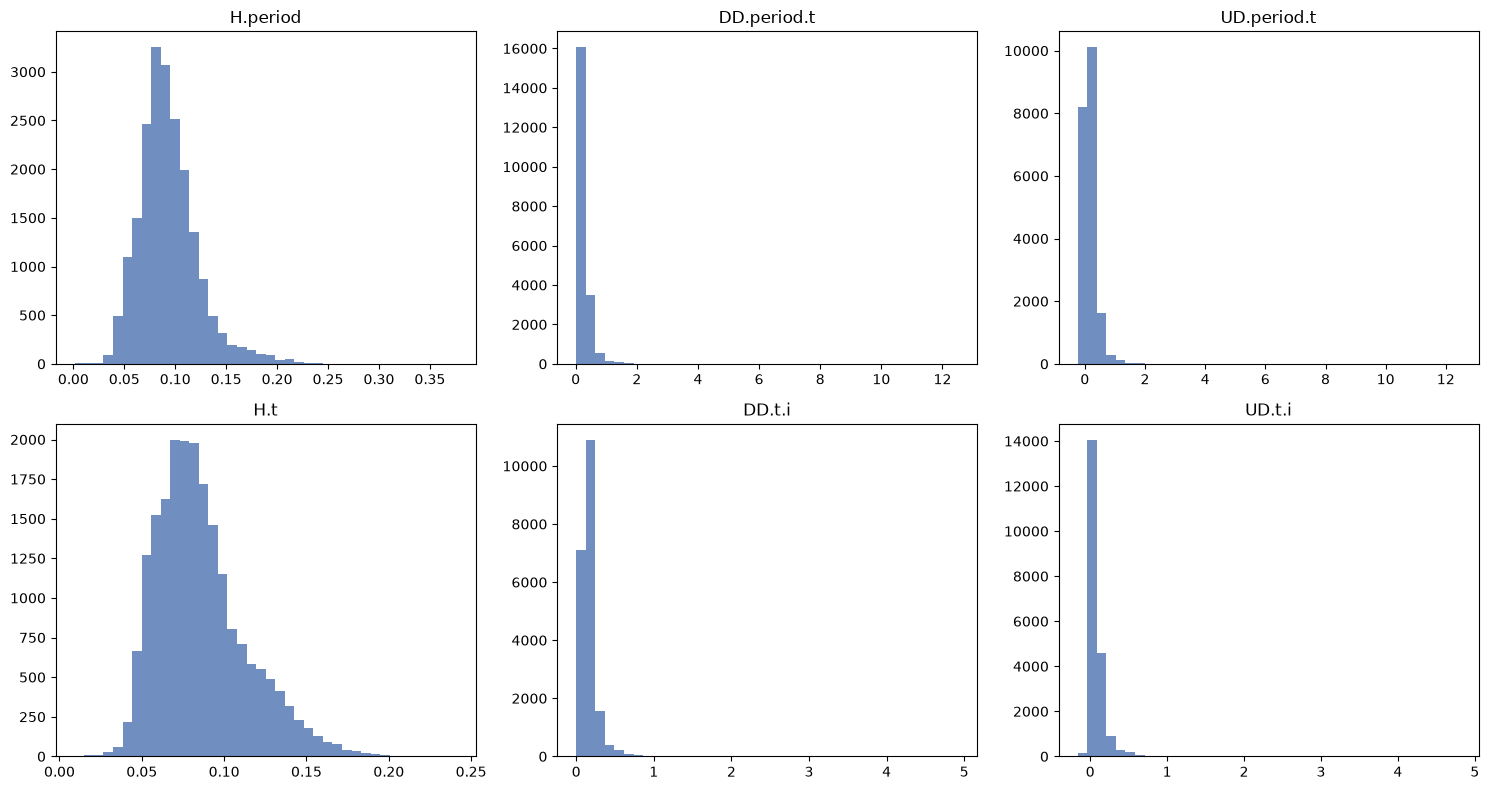

                     mean       std     min      50%      max
H.period         0.093379  0.029626  0.0014  0.08950   0.3761
DD.period.t      0.264148  0.220534  0.0187  0.20595  12.5061
UD.period.t      0.170769  0.226836 -0.2358  0.10870  12.4517
H.t              0.085727  0.027424  0.0093  0.08100   0.2411
DD.t.i           0.169085  0.123546  0.0011  0.14040   4.9197
UD.t.i           0.083358  0.125755 -0.1621  0.05780   4.7999
H.i              0.081565  0.026887  0.0032  0.07710   0.3312
DD.i.e           0.159372  0.226928  0.0014  0.12090  25.9873
UD.i.e           0.077806  0.228512 -0.1600  0.04120  25.9158
H.e              0.089138  0.030635  0.0021  0.08340   0.3254
DD.e.five        0.377434  0.265342  0.0013  0.28900   4.9618
UD.e.five        0.288295  0.266695 -0.1505  0.20040   4.8827
H.five           0.076904  0.021746  0.0014  0.07420   0.1989
DD.five.Shift.r  0.438887  0.260343  0.1694  0.37750   8.3702
UD.five.Shift.r  0.361983  0.260886  0.0856  0.30200   8.2908
H.Shift.

In [15]:
sample_features = feature_cols[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, sample_features):
    ax.hist(cmu[feat], bins=40, color='#4C72B0', alpha=0.8)
    ax.set_title(feat)
plt.tight_layout()
plt.savefig('cmu_feature_distributions.png', dpi=120)
plt.show()

print(cmu[feature_cols].describe().T[['mean', 'std', 'min', '50%', 'max']])

## Profile and scoring method

Profile is a median and MAD (median absolute deviation) per feature, built
from one user's enrollment attempts. Median and MAD instead of mean and
standard deviation, because keystroke timing has occasional long pauses,
and median-based statistics are less affected by a handful of extreme
values than mean-based ones.

Scoring a new attempt is a scaled Manhattan distance: sum across features
of the absolute difference from the profile median, divided by the MAD.
A low score matches the profile owner, a high score does not.

Checking this on one user first: does their own later typing score low
against their profile, and does someone else's typing score high?

In [16]:
def build_profile(enroll_data):
    profile_median = np.median(enroll_data, axis=0)
    profile_mad = np.median(np.abs(enroll_data - profile_median), axis=0)
    profile_mad = np.where(profile_mad == 0, 1e-6, profile_mad)  # avoid dividing by zero on a constant feature
    return profile_median, profile_mad

def score_distance(X, profile_median, profile_mad):
    return np.sum(np.abs(X - profile_median) / profile_mad, axis=1)

uid = 's002'
user_df = cmu[cmu['subject'] == uid]
source = user_df[user_df['sessionIndex'] == 1][feature_cols].values
target_genuine = user_df[user_df['sessionIndex'] > 1][feature_cols].values

profile_median, profile_mad = build_profile(source)
genuine_scores = score_distance(target_genuine, profile_median, profile_mad)

print(f"user: {uid}")
print(f"source (session 1) samples: {source.shape[0]}")
print(f"genuine target (sessions 2-8) scores - mean: {genuine_scores.mean():.2f}, std: {genuine_scores.std():.2f}, "
      f"min: {genuine_scores.min():.2f}, max: {genuine_scores.max():.2f}")

impostor_id = 's003'
impostor_df = cmu[cmu['subject'] == impostor_id]
impostor_target = impostor_df[impostor_df['sessionIndex'] > 1][feature_cols].values
impostor_scores = score_distance(impostor_target, profile_median, profile_mad)

print(f"\nimpostor ({impostor_id}) scored against {uid}'s profile:")
print(f"distances - mean: {impostor_scores.mean():.2f}, std: {impostor_scores.std():.2f}, "
      f"min: {impostor_scores.min():.2f}, max: {impostor_scores.max():.2f}")

user: s002
source (session 1) samples: 50
genuine target (sessions 2-8) scores - mean: 68.92, std: 21.24, min: 34.73, max: 220.20

impostor (s003) scored against s002's profile:
distances - mean: 131.63, std: 37.10, min: 51.37, max: 249.05


## Checking more than one user

One user is not enough to trust this. Repeating the same check across six
users and plotting genuine vs impostor score distributions for each, to
see whether the separation above is typical or a fluke.

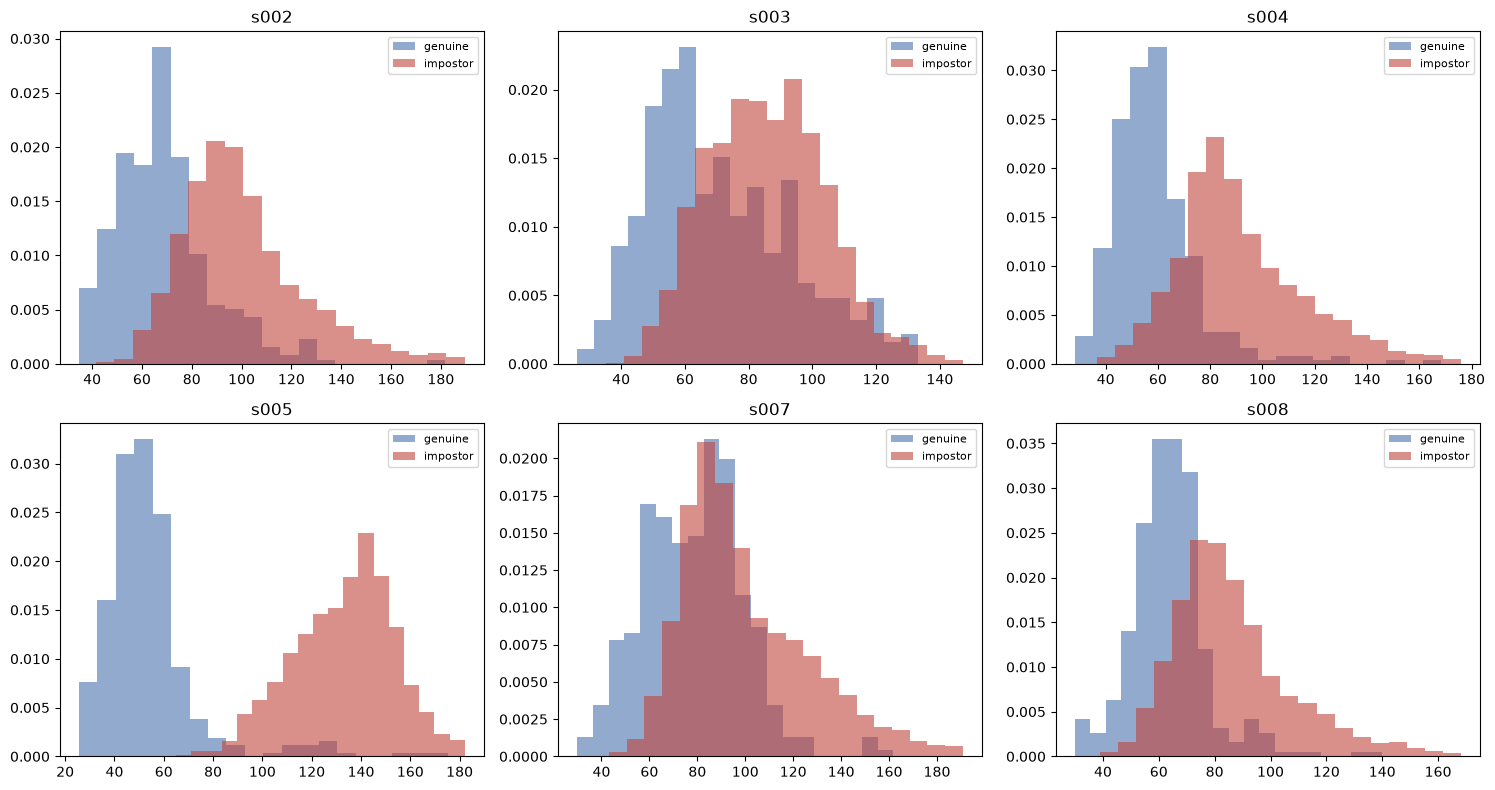

In [17]:
sample_ids = cmu['subject'].unique()[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, sid in zip(axes.flat, sample_ids):
    u_df = cmu[cmu['subject'] == sid]
    src = u_df[u_df['sessionIndex'] == 1][feature_cols].values
    tgt_gen = u_df[u_df['sessionIndex'] > 1][feature_cols].values

    p_median, p_mad = build_profile(src)
    gen_scores = score_distance(tgt_gen, p_median, p_mad)

    impostor_ids = [s for s in cmu['subject'].unique() if s != sid][:10]
    imp_df = cmu[(cmu['subject'].isin(impostor_ids)) & (cmu['sessionIndex'] > 1)]
    imp_scores = score_distance(imp_df[feature_cols].values, p_median, p_mad)

    display_max = np.percentile(np.concatenate([gen_scores, imp_scores]), 99)
    ax.hist(gen_scores[gen_scores <= display_max], bins=20, alpha=0.6, label='genuine', color='#4C72B0', density=True)
    ax.hist(imp_scores[imp_scores <= display_max], bins=20, alpha=0.6, label='impostor', color='#C1443D', density=True)
    ax.set_title(sid)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('cmu_score_distribution_check.png', dpi=120)
plt.show()

In [18]:
all_subjects = sorted(cmu['subject'].unique())
rng.shuffle(all_subjects := list(all_subjects))

n_validation = 15
validation_users = all_subjects[:n_validation]
holdout_users = all_subjects[n_validation:]

print(f"{len(validation_users)} validation users, {len(holdout_users)} holdout users")


15 validation users, 36 holdout users


## Validation and holdout split

Splitting subjects into two groups: validation users, used only to choose
alpha and target_far, and holdout users, touched once for the final
result.

#### Fitting a profile and threshold per user

Same profile and scoring method as above, applied per user. Enrollment
data is a random 60% of that user's session-1 attempts, and a strict
access threshold is picked from the other 40% (their own held-out
attempts) against everyone else's attempts. The threshold is chosen by
balanced accuracy, so a threshold that just rejects almost everyone can't
fake a high score on an evaluation where impostor attempts far outnumber
genuine ones.

In [19]:
def compute_threshold_and_curve_cmu(uid, data, feature_cols, enroll_frac=0.6, random_state=42):
    """
    Build a user's profile from an enrollment split of their session 1,
    and pick a strict access threshold from the remaining session-1 data
    (that user's genuine attempts) against everyone else's attempts
    (impostors). Returns everything needed to evaluate this user later,
    including the arrays used to compute the threshold (so the same ROC
    curve can also be used for threshold_at_far).
    """
    user_data = data[data['subject'] == uid]
    session1 = user_data[user_data['sessionIndex'] == 1][feature_cols].to_numpy()

    n_enroll = int(len(session1) * enroll_frac)
    rs = np.random.default_rng(random_state)
    idx = rs.permutation(len(session1))
    enroll_idx, heldout_idx = idx[:n_enroll], idx[n_enroll:]

    enroll_data = session1[enroll_idx]
    heldout_genuine = session1[heldout_idx]

    profile_median, profile_mad = build_scaled_manhattan_profile(enroll_data)

    impostor_data = data[data['subject'] != uid][feature_cols].to_numpy()

    genuine_scores = scaled_manhattan_batch(heldout_genuine, profile_median, profile_mad)
    impostor_scores = scaled_manhattan_batch(impostor_data, profile_median, profile_mad)

    y_true = np.concatenate([np.zeros(len(genuine_scores)), np.ones(len(impostor_scores))])
    y_score = np.concatenate([genuine_scores, impostor_scores])

    strict_threshold = find_balanced_accuracy_threshold(y_true, y_score)

    return {
        'profile_median': profile_median,
        'profile_mad': profile_mad,
        'strict_threshold': strict_threshold,
        'y_true': y_true,
        'y_score': y_score,
    }

## Fixed baseline

Profile is built once and never updated. Evaluating it against each later
session (2 through 8) separately, then averaging. This is the number the
adaptive version below has to beat.

In [20]:
def evaluate_fixed_baseline_cmu(uid, data, feature_cols):
    fit = compute_threshold_and_curve_cmu(uid, data, feature_cols)
    profile_median, profile_mad = fit['profile_median'], fit['profile_mad']
    threshold = fit['strict_threshold']

    user_data = data[data['subject'] == uid]
    later_sessions = user_data[user_data['sessionIndex'] > 1]
    genuine_scores = scaled_manhattan_batch(later_sessions[feature_cols].to_numpy(), profile_median, profile_mad)
    frr = np.mean(genuine_scores > threshold)

    impostor_data = data[data['subject'] != uid][feature_cols].to_numpy()
    impostor_scores = scaled_manhattan_batch(impostor_data, profile_median, profile_mad)
    far = np.mean(impostor_scores <= threshold)

    y_true = np.concatenate([np.zeros(len(genuine_scores)), np.ones(len(impostor_scores))])
    y_score = np.concatenate([genuine_scores, impostor_scores])
    fpr, tpr, _ = roc_curve(y_true, y_score)
    eer = fpr[np.nanargmin(np.abs(fpr - (1 - tpr)))]
    accuracy = 1 - (far + frr) / 2

    return {'far': far, 'frr': frr, 'eer': eer, 'accuracy': accuracy}


baseline_results = [evaluate_fixed_baseline_cmu(uid, cmu, feature_cols) for uid in holdout_users]
baseline_df = pd.DataFrame(baseline_results)
print(baseline_df[['far', 'frr', 'eer', 'accuracy']].mean())

far         0.075894
frr         0.391190
eer         0.183571
accuracy    0.766458
dtype: float64


## Adaptive version

Same profile as the baseline, but the profile mean updates after each
accepted attempt, as a weighted average of the old mean and the new
attempt (controlled by alpha). A second, looser threshold decides what
the profile is allowed to learn from even when an attempt did not pass
the strict threshold, set to a chosen target false accept rate instead of
an arbitrary margin.

In [21]:
def adaptive_evaluate_user_cmu(uid, data, feature_cols, alpha, target_far, enroll_frac=0.6, random_state=42):
    fit = compute_threshold_and_curve_cmu(uid, data, feature_cols, enroll_frac, random_state)
    profile_mean = fit['profile_median'].copy()
    profile_mad = fit['profile_mad']
    strict_threshold = fit['strict_threshold']
    adapt_threshold = threshold_at_far(fit['y_true'], fit['y_score'], target_far)

    user_data = data[data['subject'] == uid]
    later_sessions = user_data[user_data['sessionIndex'] > 1].sort_values(['sessionIndex', 'rep'])

    outcomes = []
    n_adapted = 0
    for _, row in later_sessions.iterrows():
        attempt = row[feature_cols].to_numpy(dtype=float)
        score = scaled_manhattan_batch(attempt.reshape(1, -1), profile_mean, profile_mad)[0]

        accepted = score <= strict_threshold
        outcomes.append({'score': score, 'accepted': accepted})

        if score <= adapt_threshold:
            profile_mean = (1 - alpha) * profile_mean + alpha * attempt
            n_adapted += 1

    genuine_scores = np.array([o['score'] for o in outcomes])
    frr = np.mean(genuine_scores > strict_threshold)

    impostor_data = data[data['subject'] != uid][feature_cols].to_numpy()
    impostor_scores = scaled_manhattan_batch(impostor_data, profile_mean, profile_mad)
    far = np.mean(impostor_scores <= strict_threshold)

    all_y_true = np.concatenate([np.zeros(len(genuine_scores)), np.ones(len(impostor_scores))])
    all_y_score = np.concatenate([genuine_scores, impostor_scores])
    fpr, tpr, _ = roc_curve(all_y_true, all_y_score)
    eer = fpr[np.nanargmin(np.abs(fpr - (1 - tpr)))]
    accuracy = 1 - (far + frr) / 2

    return {'far': far, 'frr': frr, 'eer': eer, 'accuracy': accuracy, 'n_adapted': n_adapted}


## Choosing alpha and target_far

Testing a grid of both values against validation users only, and keeping
the combination with the lowest combined false accept and false reject
rate. Holdout users are not touched here.

In [22]:
alpha_grid = [0.05, 0.10, 0.20, 0.30]
target_far_grid = [0.01, 0.02, 0.05, 0.10]

sweep_results = []
for alpha in alpha_grid:
    for target_far in target_far_grid:
        fars, frrs = [], []
        for uid in validation_users:
            r = adaptive_evaluate_user_cmu(uid, cmu, feature_cols, alpha=alpha, target_far=target_far)
            fars.append(r['far'])
            frrs.append(r['frr'])
        mean_far, mean_frr = np.mean(fars), np.mean(frrs)
        sweep_results.append({
            'alpha': alpha, 'target_far': target_far,
            'far': mean_far, 'frr': mean_frr, 'far_plus_frr': mean_far + mean_frr,
        })

sweep_df = pd.DataFrame(sweep_results).sort_values('far_plus_frr')
sweep_df.head(10)

,alpha,target_far,far,frr,far_plus_frr
11,0.2,0.10,0.100770,0.157333,0.258103
10,0.2,0.05,0.100713,0.158857,0.259570
8,0.2,0.01,0.100757,0.161905,0.262661
9,0.2,0.02,0.100757,0.161905,0.262661
15,0.3,0.10,0.095237,0.168571,0.263808
7,0.1,0.10,0.111690,0.152381,0.264071
6,0.1,0.05,0.110970,0.153333,0.264303
4,0.1,0.01,0.111147,0.155238,0.266385
5,0.1,0.02,0.111147,0.155238,0.266385
14,0.3,0.05,0.095210,0.172381,0.267591


## Locking the chosen values

Fixing whatever the sweep above picked, before running on holdout users,
so there is no chance to adjust them after seeing the final result.

In [23]:
best = sweep_df.iloc[0]
LOCKED_ALPHA = float(best['alpha'])
LOCKED_TARGET_FAR = float(best['target_far'])
print(f"Locked hyperparameters: alpha={LOCKED_ALPHA}, target_far={LOCKED_TARGET_FAR}")


Locked hyperparameters: alpha=0.2, target_far=0.1


## Final result, single-session enrollment

Run once, on holdout users only, with the locked alpha and target_far.

In [24]:
final_results = [
    adaptive_evaluate_user_cmu(uid, cmu, feature_cols, alpha=LOCKED_ALPHA, target_far=LOCKED_TARGET_FAR)
    for uid in holdout_users
]

final_far = np.mean([r['far'] for r in final_results])
final_frr = np.mean([r['frr'] for r in final_results])
final_eer = np.mean([r['eer'] for r in final_results])
final_accuracy = np.mean([r['accuracy'] for r in final_results])

print(f"Holdout results ({len(holdout_users)} users):")
print(f"  FAR:      {final_far:.3f}")
print(f"  FRR:      {final_frr:.3f}")
print(f"  EER:      {final_eer:.3f}")
print(f"  Accuracy: {final_accuracy:.3f}")

Holdout results (36 users):
  FAR:      0.093
  FRR:      0.187
  EER:      0.117
  Accuracy: 0.860
